# exp9 — seeded-contact search over ALL contact ranges (greedy)

Companion to `contact_seeding_search.ipynb` (which restricted
the candidate set to **long-range** contacts only, sep ≥ 24).
Here we let greedy search choose freely from all three contact
ranges used in training:

- `<long-range-contact>` — sep ≥ 24
- `<medium-range-contact>` — sep 12..23
- `<short-range-contact>` — sep 6..11

All three use the CB-CB ≤ 8 Å cutoff (CA for GLY / missing CB).
Adding medium + short range substantially expands the candidate
pool (90 → 240 contacts for some proteins) and also gives the
two "extended" proteins (AF-A0A1C5BRX1-F1, AF-A0A1N7G8C0-F1) a
candidate set for the first time — they have no long-range
contacts in their AFDB structure but do have short-range ones.

Algorithm: **pure greedy** (no beam) — at each round, try
`CANDIDATES_PER_ROUND` random remaining-candidate contacts,
pick the one that minimizes sample MAE. The extra candidates
from medium + short range slow the search per round, so we keep
the algorithm simple to make the run tractable.

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

EXP_DIR = Path.cwd()
REPO_ROOT = EXP_DIR.parents[1]
sys.path.insert(0, str(EXP_DIR))

import inference_helpers as IH
IH.add_exp1_to_path()

from parse import parse_structure
from select_test_proteins import select_test_proteins, download_cif

print("repo root:", REPO_ROOT)

repo root: /home/bizon/git/MarinFold-checkout2


## Resolve `1B` model + same 10 test proteins

In [2]:
with (REPO_ROOT / "MODELS.yaml").open() as fh:
    models = yaml.safe_load(fh)

MODEL_NICK = "1B"
model_entry = next(m for m in models if m["nickname"] == MODEL_NICK)
assert "contacts-and-distances-v1" in model_entry["document_structures"], model_entry
MODEL_HF_URL = model_entry["url"]
_, _, tail = MODEL_HF_URL.partition("huggingface.co/")
parts = tail.split("/")
MODEL_REPO = "/".join(parts[:2])
MODEL_SUBFOLDER = parts[4] if len(parts) > 4 and parts[2] == "tree" else None
print(f"using model: {MODEL_NICK} = {MODEL_REPO}/{MODEL_SUBFOLDER}")

SEED = 0
N_PROTEINS = 10
MAX_SEQ_LEN = 150
specs = select_test_proteins(n=N_PROTEINS, seed=SEED, max_seq_len=MAX_SEQ_LEN)
CACHE_DIR = EXP_DIR / "data" / "afdb_cache"
structures = []
for spec in specs:
    cif_path = download_cif(spec, CACHE_DIR)
    parsed = parse_structure(cif_path)
    structures.append((spec, parsed))
    print(f"  {spec.entry_id}: {len(parsed.residues)} residues")

using model: 1B = timodonnell/LlamaFold-experiments/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

select_test_proteins: skipped 4 retired entries: ['AF-A0A352P7D8-F1', 'AF-A0A1K1WRR2-F1', 'AF-A0A6M1XDR8-F1', 'AF-A6D053-F1']
  AF-A0A1C5BRX1-F1: 72 residues
  AF-A0A2P2Q6H4-F1: 55 residues
  AF-E6UJZ8-F1: 112 residues
  AF-A0A1G4A0Q3-F1: 114 residues
  AF-A0A6B0Z5B5-F1: 112 residues
  AF-A0A7W4UDR7-F1: 131 residues
  AF-C6S3E2-F1: 140 residues
  AF-A0A1N7G8C0-F1: 60 residues
  AF-R7G5V6-F1: 132 residues
  AF-A0A1H0PBF4-F1: 94 residues


In [3]:
os.environ.setdefault("VLLM_LOGGING_LEVEL", "WARNING")

from huggingface_hub import snapshot_download

MODEL_LOCAL = Path(snapshot_download(
    repo_id=MODEL_REPO,
    allow_patterns=[f"{MODEL_SUBFOLDER}/*"] if MODEL_SUBFOLDER else None,
))
if MODEL_SUBFOLDER:
    MODEL_LOCAL = MODEL_LOCAL / MODEL_SUBFOLDER
print("model local path:", MODEL_LOCAL)

llm, tokenizer = IH.load_vllm(MODEL_LOCAL)
DISTANCE_TOKEN_IDS = IH.resolve_distance_token_ids(tokenizer)
print(f"resolved {len(DISTANCE_TOKEN_IDS)} distance tokens")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model local path: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/2922df683506f2549a02633d8ddcaa4d9df8900b/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 05-19 11:32:14 cuda.py:95] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used


WARNING 05-19 11:32:14 config.py:685] Async output processing is not supported on the current platform type cuda.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


resolved 64 distance tokens


## Candidate counts by range

Quick sanity check before the search — confirms there's
something to pick for every protein.

In [4]:
candidate_pools = {}
for spec, parsed in structures:
    all_c = IH.gt_contacts_all_ranges(parsed)
    n_long = sum(1 for c in all_c if c[0] == "<long-range-contact>")
    n_med = sum(1 for c in all_c if c[0] == "<medium-range-contact>")
    n_short = sum(1 for c in all_c if c[0] == "<short-range-contact>")
    candidate_pools[spec.entry_id] = all_c
    print(f"  {spec.entry_id}: long={n_long:>3}  medium={n_med:>3}  short={n_short:>3}  total={len(all_c):>4}")

  AF-A0A1C5BRX1-F1: long=  0  medium=  0  short=  4  total=   4
  AF-A0A2P2Q6H4-F1: long= 17  medium= 41  short= 22  total=  80
  AF-E6UJZ8-F1: long=113  medium= 18  short= 31  total= 162
  AF-A0A1G4A0Q3-F1: long= 45  medium= 14  short= 13  total=  72
  AF-A0A6B0Z5B5-F1: long= 59  medium= 20  short= 12  total=  91
  AF-A0A7W4UDR7-F1: long=116  medium= 71  short= 56  total= 243
  AF-C6S3E2-F1: long=156  medium= 45  short= 29  total= 230
  AF-A0A1N7G8C0-F1: long=  0  medium=  0  short=  2  total=   2
  AF-R7G5V6-F1: long= 21  medium=  3  short= 16  total=  40
  AF-A0A1H0PBF4-F1: long= 37  medium=  0  short= 10  total=  47


## Pure-greedy search per protein

Per round we try `CANDIDATES_PER_ROUND` random remaining
candidates (across all three ranges) and pick the one
minimizing the 300-pair sample MAE. Stop early at the target
MAE or when `MAX_CONTACTS` is reached.

In [5]:
SAMPLE_PAIRS = 300
TARGET_MAE = 1.0
MAX_CONTACTS = 30
CANDIDATES_PER_ROUND = 10
PAIR_SAMPLE_SEED = 1
CAND_RNG_SEED = 2


def greedy_search_all_ranges(spec, parsed):
    """Greedy seeded-contact search over ALL ranges (long+medium+short).

    Selected contact entries are 3-tuples ``(type_token, i, j)`` so
    the prompt builder emits the right range-specific contact
    statement (`<long-range-contact>`, `<medium-range-contact>`,
    `<short-range-contact>`).
    """
    pair_seed = hash((spec.entry_id, PAIR_SAMPLE_SEED)) & 0xFFFFFFFF
    sample_pairs = IH.sample_ca_pairs(parsed, SAMPLE_PAIRS, seed=pair_seed)
    candidates = candidate_pools[spec.entry_id]
    if not candidates:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": 0,
            "trace": [],
            "selected_contacts": [],
            "search_terminated": "no candidate contacts at any range",
        }
    cand_rng = np.random.default_rng(
        hash((spec.entry_id, CAND_RNG_SEED)) & 0xFFFFFFFF)

    selected: list[tuple[str, int, int]] = []
    trace = []

    def measure(contacts):
        pred = IH.predict_at_pairs(
            llm=llm,
            tokenizer=tokenizer,
            parsed=parsed,
            pairs=sample_pairs,
            seeded_contacts=contacts,
            distance_token_ids=DISTANCE_TOKEN_IDS,
        )
        return IH.mae_on_pairs(parsed, sample_pairs, pred)

    t0 = time.time()
    base_mae, base_n = measure([])
    print(f"  k=0 sample MAE = {base_mae:.3f} Å (n={base_n})")
    trace.append({
        "k": 0,
        "added_contact": None,
        "sample_mae_angstrom": base_mae,
        "elapsed_seconds": time.time() - t0,
    })
    if base_mae < TARGET_MAE:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": len(candidates),
            "trace": trace,
            "selected_contacts": [],
            "search_terminated": "target met at k=0",
        }

    while len(selected) < MAX_CONTACTS:
        remaining = [c for c in candidates if c not in selected]
        if not remaining:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": selected,
                "search_terminated": "exhausted candidates",
            }
        if len(remaining) > CANDIDATES_PER_ROUND:
            idx = cand_rng.choice(len(remaining), size=CANDIDATES_PER_ROUND, replace=False)
            this_round = [remaining[i] for i in sorted(idx)]
        else:
            this_round = remaining
        t0 = time.time()
        best_mae = float("inf")
        best_contact = None
        for cand in this_round:
            trial = selected + [cand]
            mae, _ = measure(trial)
            if mae < best_mae:
                best_mae = mae
                best_contact = cand
        elapsed = time.time() - t0
        selected.append(best_contact)
        type_short = best_contact[0].strip("<>").replace("-range-contact", "")
        trace.append({
            "k": len(selected),
            "added_contact": best_contact,
            "added_contact_type": type_short,
            "sample_mae_angstrom": best_mae,
            "n_tried_this_round": len(this_round),
            "n_remaining_before_cap": len(remaining),
            "elapsed_seconds": elapsed,
        })
        print(f"  k={len(selected)} +{type_short}({best_contact[1]},{best_contact[2]}) "
              f"-> sample MAE = {best_mae:.3f} Å "
              f"(tried {len(this_round)}/{len(remaining)} cands in {elapsed:.1f}s)")
        if best_mae < TARGET_MAE:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": selected,
                "search_terminated": f"target met at k={len(selected)}",
            }

    return {
        "entry_id": spec.entry_id,
        "n_candidates": len(candidates),
        "trace": trace,
        "selected_contacts": selected,
        "search_terminated": f"reached MAX_CONTACTS={MAX_CONTACTS}",
    }


results = []
for spec, parsed in structures:
    print(f"\n{spec.entry_id} ({len(parsed.residues)} residues, {len(candidate_pools[spec.entry_id])} candidates):")
    res = greedy_search_all_ranges(spec, parsed)
    print(f"  -> {res['search_terminated']}; selected {len(res['selected_contacts'])} contacts")
    results.append(res)


AF-A0A1C5BRX1-F1 (72 residues, 4 candidates):


  k=0 sample MAE = 2.851 Å (n=224)


  k=1 +short(29,40) -> sample MAE = 2.262 Å (tried 4/4 cands in 3.4s)


  k=2 +short(29,37) -> sample MAE = 2.270 Å (tried 3/3 cands in 2.7s)


  k=3 +short(32,40) -> sample MAE = 2.256 Å (tried 2/2 cands in 1.7s)


...

  k=4 +long(30,75) -> sample MAE = 1.459 Å (tried 10/44 cands in 11.4s)


  k=5 +long(43,89) -> sample MAE = 1.359 Å (tried 10/43 cands in 11.6s)


  k=6 +short(41,49) -> sample MAE = 1.186 Å (tried 10/42 cands in 11.6s)


  k=7 +long(28,78) -> sample MAE = 1.081 Å (tried 10/41 cands in 12.1s)


  k=8 +long(46,87) -> sample MAE = 0.968 Å (tried 10/40 cands in 12.2s)
  -> target met at k=8; selected 8 contacts


## Final full-matrix MAE with the selected contacts

In [6]:
final_predicted = {}
final_gt = {}
for (spec, parsed), res in zip(structures, results, strict=True):
    seeded = res["selected_contacts"]
    print(f"  {spec.entry_id}: running full matrix with {len(seeded)} seeded contacts")
    t0 = time.time()
    pred = IH.predict_distance_matrix(
        llm=llm,
        tokenizer=tokenizer,
        parsed=parsed,
        seeded_contacts=seeded,
        distance_token_ids=DISTANCE_TOKEN_IDS,
    )
    gt = IH.ca_distance_matrix(parsed)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    full_mae = float(np.abs(pred - gt)[valid & np.isfinite(pred)].mean())
    res["full_matrix_mae_angstrom"] = full_mae
    res["full_matrix_n_valid_pairs"] = int(valid.sum())
    final_predicted[spec.entry_id] = pred
    final_gt[spec.entry_id] = gt
    print(f"    full-matrix MAE = {full_mae:.3f} Å ({time.time()-t0:.1f}s)")

  AF-A0A1C5BRX1-F1: running full matrix with 4 seeded contacts


    full-matrix MAE = 2.486 Å (7.9s)
  AF-A0A2P2Q6H4-F1: running full matrix with 15 seeded contacts


    full-matrix MAE = 0.946 Å (5.3s)
  AF-E6UJZ8-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.277 Å (39.8s)
  AF-A0A1G4A0Q3-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.343 Å (41.6s)
  AF-A0A6B0Z5B5-F1: running full matrix with 7 seeded contacts


...

    full-matrix MAE = 1.460 Å (59.4s)
  AF-C6S3E2-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.918 Å (70.1s)
  AF-A0A1N7G8C0-F1: running full matrix with 0 seeded contacts


    full-matrix MAE = 1.035 Å (4.5s)
  AF-R7G5V6-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.241 Å (60.3s)
  AF-A0A1H0PBF4-F1: running full matrix with 8 seeded contacts


    full-matrix MAE = 1.033 Å (17.8s)


## Per-protein summary

In [7]:
import csv

PLOTS_DIR = EXP_DIR / "plots"
DATA_DIR = EXP_DIR / "data"
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f"{'entry_id':<24} {'n_res':>5} {'cands':>6} {'k':>4} {'long':>4} {'med':>4} {'short':>5} {'sample_MAE':>11} {'full_MAE':>10}  status")
rows = []
for (spec, parsed), res in zip(structures, results, strict=True):
    k = len(res["selected_contacts"])
    sel = res["selected_contacts"]
    n_long = sum(1 for c in sel if c[0] == "<long-range-contact>")
    n_med = sum(1 for c in sel if c[0] == "<medium-range-contact>")
    n_short = sum(1 for c in sel if c[0] == "<short-range-contact>")
    sample_mae = res["trace"][-1]["sample_mae_angstrom"] if res["trace"] else float("nan")
    full_mae = res.get("full_matrix_mae_angstrom", float("nan"))
    rows.append({
        "entry_id": spec.entry_id,
        "uniprot_accession": spec.uniprot_accession,
        "n_residues": len(parsed.residues),
        "n_candidate_contacts": res["n_candidates"],
        "k_selected": k,
        "n_long_selected": n_long,
        "n_medium_selected": n_med,
        "n_short_selected": n_short,
        "selected_contacts": "; ".join(
            f"{c[0].strip('<>').replace('-range-contact','')}:{c[1]}-{c[2]}" for c in sel),
        "final_sample_mae_angstrom": sample_mae,
        "full_matrix_mae_angstrom": full_mae,
        "search_terminated": res["search_terminated"],
    })
    print(f"{spec.entry_id:<24} {len(parsed.residues):>5} {res['n_candidates']:>6} "
          f"{k:>4} {n_long:>4} {n_med:>4} {n_short:>5} "
          f"{sample_mae:>11.3f} {full_mae:>10.3f}  {res['search_terminated']}")

with (DATA_DIR / "contact_search_all_ranges_summary.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0]))
    w.writeheader()
    w.writerows(rows)
print(f"\nwrote {(DATA_DIR / 'contact_search_all_ranges_summary.csv').relative_to(REPO_ROOT)}")

entry_id                 n_res  cands    k long  med short  sample_MAE   full_MAE  status
AF-A0A1C5BRX1-F1            72      4    4    0    0     4       2.475      2.486  exhausted candidates
AF-A0A2P2Q6H4-F1            55     80   15    6    5     4       0.982      0.946  target met at k=15
AF-E6UJZ8-F1               112    162   30   22    4     4       1.214      1.277  reached MAX_CONTACTS=30
AF-A0A1G4A0Q3-F1           114     72   30   17    8     5       1.214      1.343  reached MAX_CONTACTS=30
AF-A0A6B0Z5B5-F1           112     91    7    6    1     0       0.942      1.012  target met at k=7
AF-A0A7W4UDR7-F1           131    243   30   19    5     6       1.220      1.460  reached MAX_CONTACTS=30
AF-C6S3E2-F1               140    230   30   21    4     5       1.769      1.918  reached MAX_CONTACTS=30
AF-A0A1N7G8C0-F1            60      2    0    0    0     0       0.964      1.035  target met at k=0
AF-R7G5V6-F1               132     40   30   16    2    12       1.131    

## Trace plot

One line per protein. Horizontal red dash = 1.0 Å target.

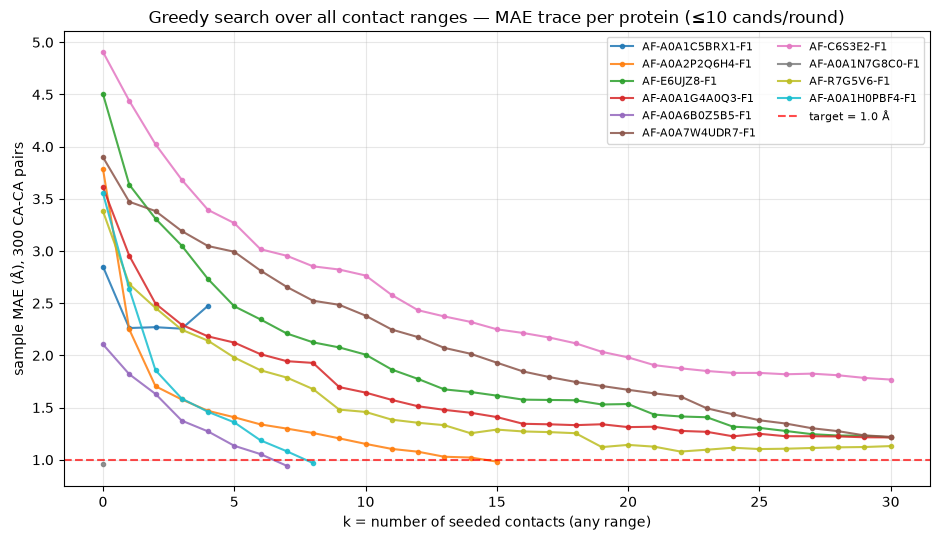

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for (spec, _), res in zip(structures, results, strict=True):
    if not res["trace"]:
        continue
    ks = [step["k"] for step in res["trace"]]
    maes = [step["sample_mae_angstrom"] for step in res["trace"]]
    ax.plot(ks, maes, "-o", markersize=3, label=spec.entry_id, alpha=0.85)
ax.axhline(TARGET_MAE, color="red", linestyle="--", alpha=0.7, label=f"target = {TARGET_MAE} Å")
ax.set_xlabel("k = number of seeded contacts (any range)")
ax.set_ylabel(f"sample MAE (Å), {SAMPLE_PAIRS} CA-CA pairs")
ax.set_title(f"Greedy search over all contact ranges — MAE trace per protein "
             f"(≤{CANDIDATES_PER_ROUND} cands/round)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "contact_search_all_ranges_trace.png", dpi=110)
plt.show()

## Final heatmaps with selected contacts (10 × 3 grid)

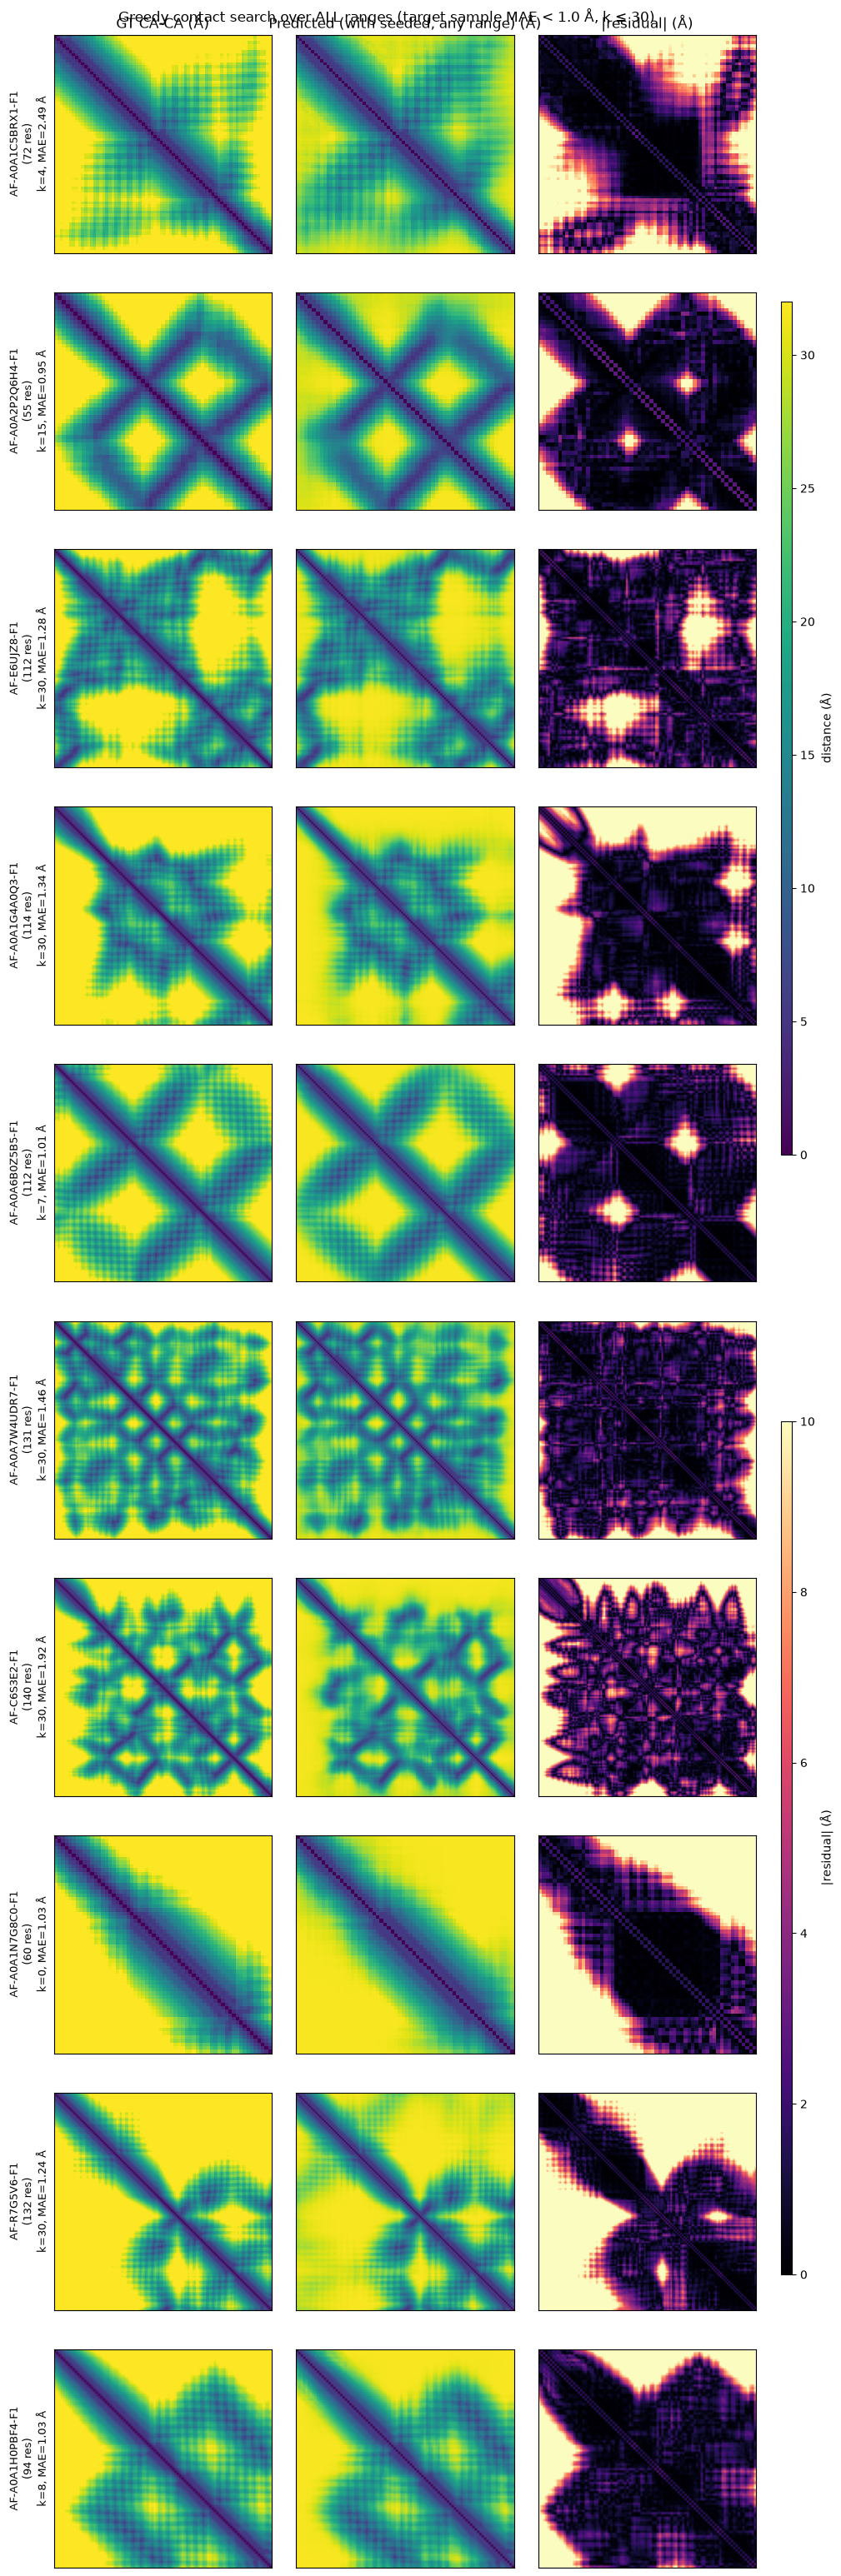

saved experiments/exp9_evals_test_distance_heatmaps/plots/contact_search_all_ranges_grid.png


In [9]:
n_proteins = len(structures)
fig, axes = plt.subplots(n_proteins, 3, figsize=(11, 3.2 * n_proteins), squeeze=False)
for row, ((spec, parsed), res) in enumerate(zip(structures, results, strict=True)):
    gt = final_gt[spec.entry_id]
    pred = final_predicted[spec.entry_id]
    abs_err = np.abs(pred - gt)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    mae = res["full_matrix_mae_angstrom"]
    k = len(res["selected_contacts"])

    im0 = axes[row, 0].imshow(gt, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im1 = axes[row, 1].imshow(pred, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im2 = axes[row, 2].imshow(abs_err, vmin=0, vmax=10.0, cmap="magma")

    axes[row, 0].set_ylabel(f"{spec.entry_id}\n({n} res)\nk={k}, MAE={mae:.2f} Å", fontsize=9)
    if row == 0:
        axes[row, 0].set_title("GT CA-CA (Å)")
        axes[row, 1].set_title("Predicted (with seeded, any range) (Å)")
        axes[row, 2].set_title("|residual| (Å)")
    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

cbar_dist = fig.add_axes([0.93, 0.55, 0.012, 0.32])
fig.colorbar(im1, cax=cbar_dist, label="distance (Å)")
cbar_err = fig.add_axes([0.93, 0.13, 0.012, 0.32])
fig.colorbar(im2, cax=cbar_err, label="|residual| (Å)")
fig.suptitle(
    f"Greedy contact search over ALL ranges (target sample MAE < {TARGET_MAE} Å, k ≤ {MAX_CONTACTS})",
    fontsize=12,
)
fig.subplots_adjust(left=0.13, right=0.91, top=0.97, bottom=0.02, hspace=0.18, wspace=0.05)
fig.savefig(PLOTS_DIR / "contact_search_all_ranges_grid.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"saved {(PLOTS_DIR / 'contact_search_all_ranges_grid.png').relative_to(REPO_ROOT)}")

## Summary

Adds the medium- and short-range contact types to the candidate
pool, runs pure greedy. Compare to
`contact_seeding_search.ipynb` (beam-2, long-range only) to see
whether the extra short / medium contacts let more proteins
reach 1 Å MAE.